## CNN

- pasar a tf??
- errores --> ver algun ejemplo unico  

In [2]:
# baseline cnn model for fashion mnist
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "False"
# os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'
from numpy import mean
from numpy import std
from matplotlib import pyplot
from sklearn.model_selection import KFold
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import SGD

In [5]:
!pip install torch

In [6]:
import torch
torch.cuda.is_available()

False

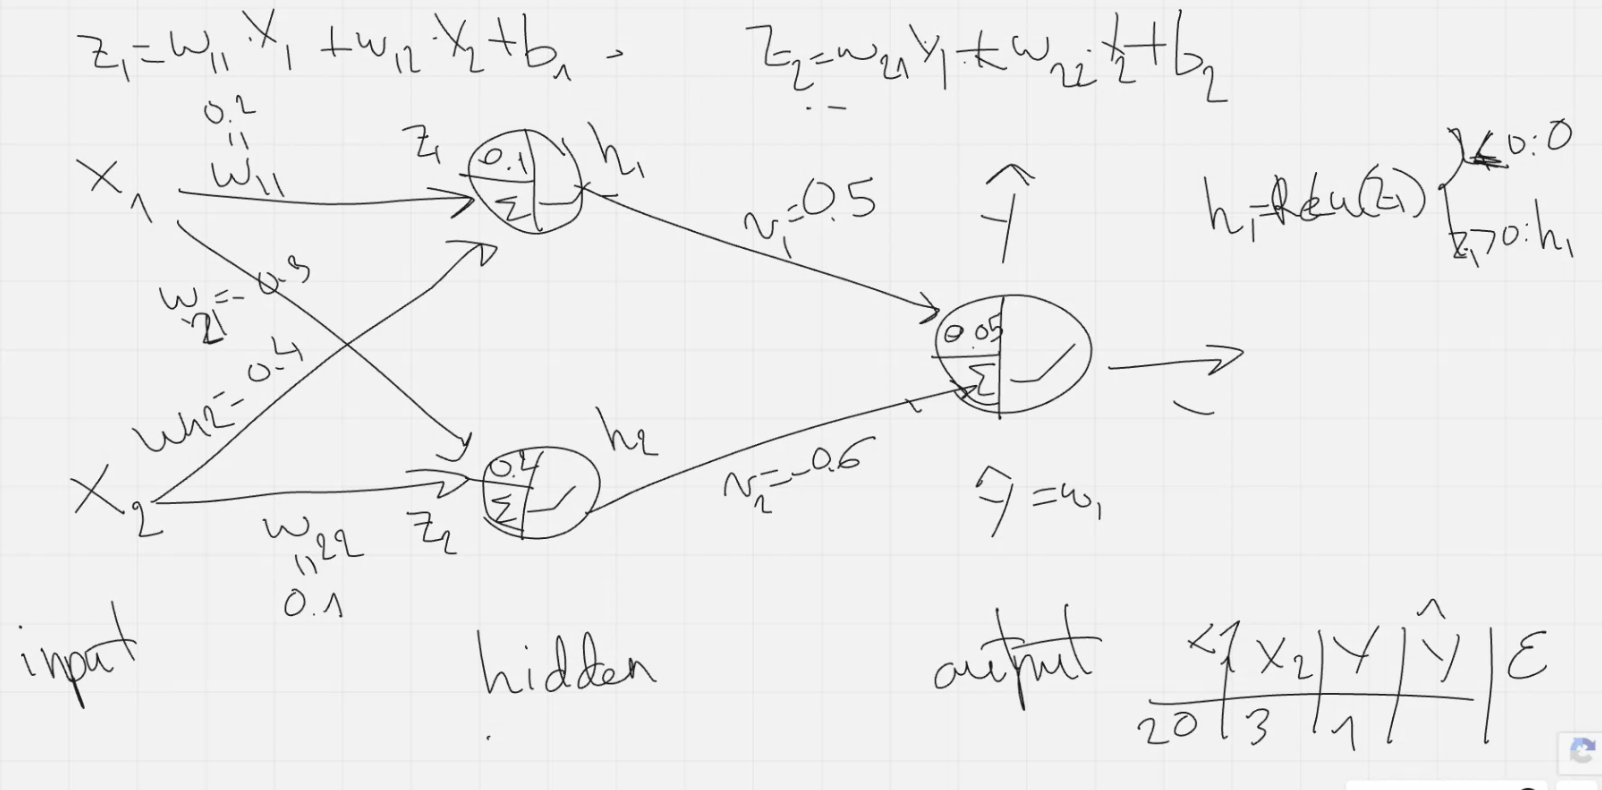

In [7]:
from IPython.display import Image
Image(r"C:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\EVOLVE\Tomas_Arteaga_ML\Deep Learning\Notebooks_Clase\Deep_Learning_Train_001.png")

## 0. Exploramos los datos

https://machinelearningmastery.com/how-to-develop-a-cnn-from-scratch-for-fashion-mnist-clothing-classification/

The **Fashion-MNIST dataset** is proposed as a more challenging replacement dataset for the MNIST dataset.  

It is a dataset comprised of 60,000 small square 28×28 pixel grayscale images of items of 10 types of clothing, such as shoes, t-shirts, dresses, and more. The mapping of all 0-9 integers to class labels is listed below.  

0: T-shirt/top  
1: Trouser  
2: Pullover  
3: Dress  
4: Coat  
5: Sandal  
6: Shirt  
7: Sneaker  
8: Bag  
9: Ankle boot  
It is a more challenging classification problem than MNIST and top results are achieved by deep learning convolutional neural networks with a classification accuracy of about 90% to 95% on the hold out test dataset.  

The example below loads the Fashion-MNIST dataset using the Keras API and creates a plot of the first nine images in the training dataset.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 18s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 3s 1us/step
Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


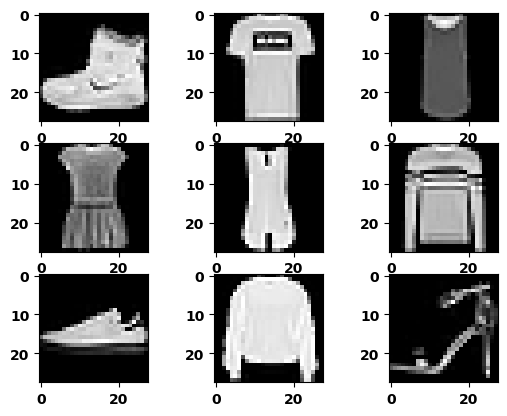

In [8]:
from matplotlib import pyplot
from tensorflow.keras.datasets import fashion_mnist
# load dataset
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()
# summarize loaded dataset
print('Train: X=%s, y=%s' % (trainX.shape, trainy.shape))
print('Test: X=%s, y=%s' % (testX.shape, testy.shape))
# plot first few images
for i in range(9):
	# define subplot
	pyplot.subplot(330 + 1 + i)
	# plot raw pixel data
	pyplot.imshow(trainX[i], cmap=pyplot.get_cmap('gray'))
# show the figure
pyplot.show()

Imagen en escala de grises: Cada valor en la matriz representa la intensidad de luz de un píxel.  
0: Representa el negro (ausencia de luz).  
255: Representa el blanco (máxima intensidad de luz).  
Los valores intermedios (entre 0 y 255) indican distintos tonos de gris.  

In [9]:
# baseline cnn model for fashion mnist
from numpy import mean
from numpy import std
from matplotlib import pyplot
from sklearn.model_selection import KFold
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import SGD

#### 1. Cargamos el dataset
Cargamos el set de tados que son imagenes en escala de grises de 28x28 pixeles  
tambien se convierte en categorica la varianle output qur toma valores de 0 a 9, una para cada categoria de ropa.  
0: T-shirt/top  
1: Trouser  
2: Pullover  
3: Dress  
4: Coat  
5: Sandal  
6: Shirt  
7: Sneaker  
8: Bag  
9: Ankle boot  

In [10]:
# load train and test dataset
def load_dataset():
	# load dataset
	(trainX, trainY), (testX, testY) = fashion_mnist.load_data()
	# reshape dataset to have a single channel
	trainX = trainX.reshape((trainX.shape[0], 28, 28, 1))
	testX = testX.reshape((testX.shape[0], 28, 28, 1))
	# one hot encode target values
	trainY = to_categorical(trainY)
	testY = to_categorical(testY)
	return trainX, trainY, testX, testY

#### 2. Prepara los pixeles  
El reshape es para que puenda procesarlos la red CNN. el 1 indica el canal. Al ser solo 1 quiere decir escala de grises.  
Si la imagen fuese en color: trainX = trainX.reshape((trainX.shape[0], 28, 28, 3)) · por cada unos de los canales RGB.  

In [11]:
# scale pixels
def prep_pixels(train, test):
	# convert from integers to floats
	train_norm = train.astype('float32')
	test_norm = test.astype('float32')
	# normalize to range 0-1
	train_norm = train_norm / 255.0
	test_norm = test_norm / 255.0
	# return normalized images
	return train_norm, test_norm


#### 3. Definimos las capas de la red neuronal

**Capas:** 
- **Conv2D**: Al tratar imagenes con CNN hay que añadir una primera capa convolucional  
- **MaxPooling2D**: realiza una operación de reducción (pooling) sobre un mapa de características 2D. Su función principal es disminuir las dimensiones espaciales (alto y ancho) de los datos, reduciendo la cantidad de parámetros y el coste computacional, y al mismo tiempo ayudando a la red a ser más robusta frente a pequeñas translaciones en la entrada.  
- **flatten**: Convierte una matriz multidimensional en un vector 1D.  
- **dense**: capa totalmente conectada donde cada neurona de una capa está conectada con todas las neuronas de la siguiente capa.

Como estamos estimando 10 categorias necesitamo una capa output de 10 nodos.  
La función **softmax** toma como entrada un vector de números reales (a menudo denominados "logits") y los transforma en una distribución de probabilidad, es decir, en un vector cuyas componentes están en el rango (0,1) y cuya suma es 1. Esto permite interpretar cada componente resultante como la probabilidad de que la muestra pertenezca a la clase correspondiente.  
Usamos tambien el optimizador basado en el metodo del gradiente (SGD): opt = SGD(learning_rate=0.01, momentum=0.9)

In [12]:

# define cnn model
def define_model():
	model = Sequential()
	model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
	model.add(MaxPooling2D((2, 2)))
	model.add(Flatten())
	model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
	model.add(Dense(10, activation='softmax'))
	# compile model
	opt = SGD(learning_rate=0.01, momentum=0.9)
	model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
	return model


#### 4. Evalua el modelo

Empleamo la validación cruzada por medio de kfolds:  

- **División del Dataset**: KFold divide el conjunto de datos en k grupos (folds) aproximadamente del mismo tamaño. Por ejemplo, si n_splits=5, el dataset se divide en 5 partes.  

- **Proceso de Validación Cruzada**: Para cada iteración del proceso, se selecciona uno de los k folds como conjunto de validación y se utilizan los otros k - 1 folds para entrenar el modelo. Este proceso se repite k veces, de forma que cada fold se utiliza una vez como conjunto de validación.  

- **Generación de Índices**: La clase proporciona métodos para obtener los índices tanto del conjunto de entrenamiento como del de validación. Esto es particularmente útil cuando se desea evaluar el modelo con diferentes particiones del dataset, y poder calcular métricas de desempeño promedio y su variabilidad.  

- **Configurabilidad**: Puedes ajustar parámetros como:  

    - n_splits: número de particiones deseadas.  
    - shuffle: si se desea mezclar (aleatorizar) los datos antes de dividirlos. Esto es importante si tus datos están ordenados.  
    - random_state: para establecer una semilla en la aleatorización y obtener particiones reproducibles.

Epochs por otro lado indica en numero de veces que le hacermos la pasada completa de estimacion de paramteros a la red neuronal (Back+Formward)

In [13]:

# evaluate a model using k-fold cross-validation
def evaluate_model(dataX, dataY, n_folds=5):
	scores, histories = list(), list()
	# prepare cross validation
	kfold = KFold(n_folds, shuffle=True, random_state=1)
	# enumerate splits
	for train_ix, test_ix in kfold.split(dataX):
		# define model
		model = define_model()
		# select rows for train and test
		trainX, trainY, testX, testY = dataX[train_ix], dataY[train_ix], dataX[test_ix], dataY[test_ix]
		# fit model
		history = model.fit(trainX, trainY, epochs=10, batch_size=32, validation_data=(testX, testY), verbose=0)
		# evaluate model
		_, acc = model.evaluate(testX, testY, verbose=0)
		print('> %.3f' % (acc * 100.0))
		# append scores
		scores.append(acc)
		histories.append(history)
	return scores, histories

#### 5. Diagnostico

Pintamos Cross Entropy Loss y Accuracy para cada una de las 5 ejecuciones y cada una de estas ejecciones tiene 10 iteraciones (10 estimaciones completas de parámetros de la neurona)  
- **Cross Entropy Loss**: es una metrica del error de clasificacion.  
- **Accuracy**: Numero de valores acertados / total de valores  



In [14]:
# plot diagnostic learning curves
def summarize_diagnostics(histories):
	for i in range(len(histories)):
		# plot loss
		pyplot.subplot(211)
		pyplot.title('Cross Entropy Loss')
		pyplot.plot(histories[i].history['loss'], color='blue', label='train')
		pyplot.plot(histories[i].history['val_loss'], color='orange', label='test')
		# plot accuracy
		pyplot.subplot(212)
		pyplot.title('Classification Accuracy')
		pyplot.plot(histories[i].history['accuracy'], color='blue', label='train')
		pyplot.plot(histories[i].history['val_accuracy'], color='orange', label='test')
	pyplot.show()


#### 6. Performance

Vemos la evolucion del accuracy para cada kfold. En scores se va guardando la accuracy de cada una de las ejecuciones para el conjunto de test

In [15]:
# summarize model performance
def summarize_performance(scores):
	# print summary
	print('Accuracy: mean=%.3f std=%.3f, n=%d' % (mean(scores)*100, std(scores)*100, len(scores)))
	# box and whisker plots of results
	pyplot.boxplot(scores)
	pyplot.show()

#### 7. Run

c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv_tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


> 90.833
> 91.050
> 90.800
> 91.433
> 91.108


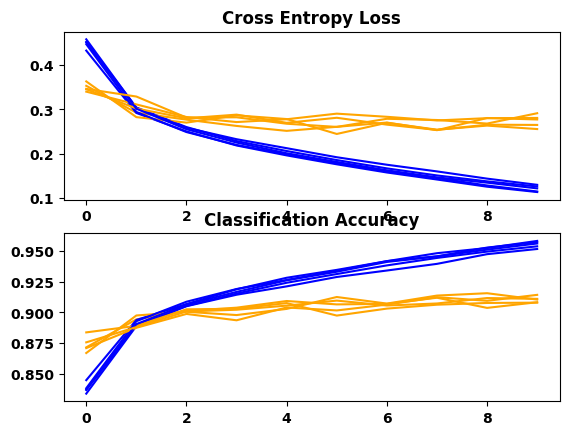

Accuracy: mean=91.045 std=0.228, n=5


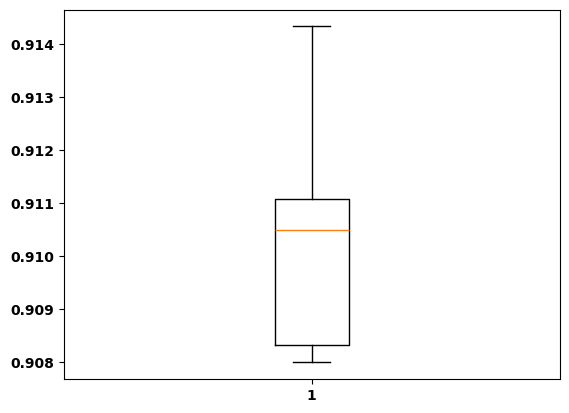

In [16]:
# run the test harness for evaluating a model
def run_test_harness():
	# load dataset
	trainX, trainY, testX, testY = load_dataset()
	# prepare pixel data
	trainX, testX = prep_pixels(trainX, testX)
	# evaluate model
	scores, histories = evaluate_model(trainX, trainY)
	# learning curves
	summarize_diagnostics(histories)
	# summarize estimated performance
	summarize_performance(scores)

# entry point, run the test harness
run_test_harness()

Las lineas azules muestras performance del train y las naranjas de test.
pinta las distribuciones del accuracy en un boxplot.

Posible mejora del modelo:  
Se puede mejorar con padding = 'same' o añadiendo mas complejidad al filtro conv2d de 32 a 64.  
Padding permite hacer uso de la información de los bordes de la imagen

#### 8. Guardamos el modelo 

Ajustamos en modelo a nuestos datos de train y lo guardamos


In [17]:
def run_save():
	# load dataset
    trainX, trainY, testX, testY = load_dataset()
	# prepare pixel data
    trainX, testX = prep_pixels(trainX, testX)
	# define model
    model = define_model()
	# fit model
    model.fit(trainX, trainY, epochs=10, batch_size=32, verbose=0)
	# save model
    model.save('final_CNN_model.h5')
    model.save('final_CNN_model.keras')
    #model.save('mi_modelo')


In [18]:
run_save()

c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv_tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 9. Errores  
Vemos en el modelo casos mal clasificados  

0: T-shirt/top  
1: Trouser  
2: Pullover  
3: Dress  
4: Coat  
5: Sandal  
6: Shirt  
7: Sneaker  
8: Bag  
9: Ankle boot 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Número de casos mal clasificados: 1419


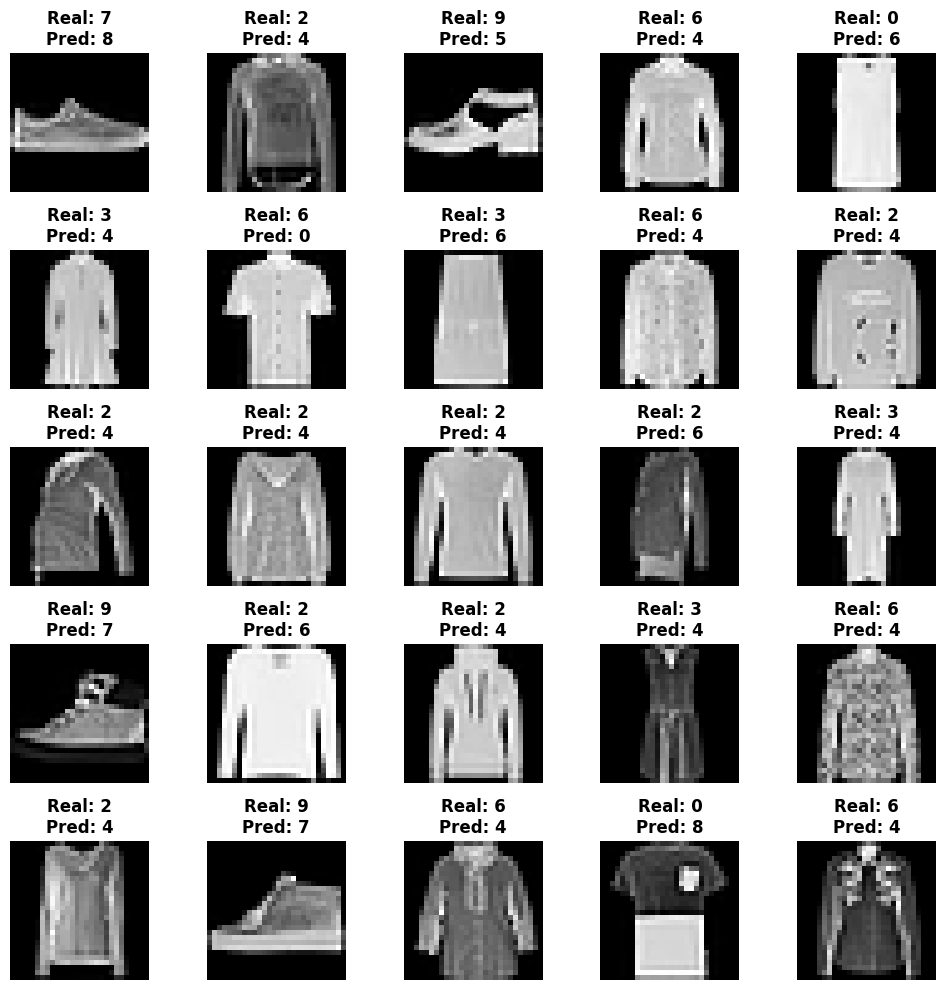

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model('final_CNN_model.keras')
# 1. Obtén las predicciones del modelo
predicciones = model.predict(testX)  # x_test: conjunto de datos de prueba
# Si y_test está en formato one-hot encoded:
predicted_classes = np.argmax(predicciones, axis=1)
#true_classes = np.argmax(tes)
true_classes = testy
# 2. Identifica los casos mal clasificados
misclassified_idx = np.where(predicted_classes != true_classes)[0]
print("Número de casos mal clasificados:", len(misclassified_idx))

# 3. Visualiza algunos ejemplos (por ejemplo, los primeros 25 casos erróneos)
plt.figure(figsize=(10, 10))
for i, idx in enumerate(misclassified_idx[:25]):
    plt.subplot(5, 5, i + 1)
    # Si tus imágenes son en escala de grises y tienen canal único:
    if testX.shape[-1] == 1:
        plt.imshow(testX[idx].reshape(testX.shape[1], testX.shape[2]), cmap='gray')
        
    else:
        plt.imshow(testX[idx], cmap='gray')
    plt.title(f"Real: {true_classes[idx]}\nPred: {predicted_classes[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

#### 10. Evaluamos el modelo

In [20]:
# evaluate the deep model on the test dataset
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
 
# load train and test dataset
def load_dataset():
	# load dataset
	(trainX, trainY), (testX, testY) = fashion_mnist.load_data()
	# reshape dataset to have a single channel
	trainX = trainX.reshape((trainX.shape[0], 28, 28, 1))
	testX = testX.reshape((testX.shape[0], 28, 28, 1))
	# one hot encode target values
	trainY = to_categorical(trainY)
	testY = to_categorical(testY)
	return trainX, trainY, testX, testY
 
# scale pixels
def prep_pixels(train, test):
	# convert from integers to floats
	train_norm = train.astype('float32')
	test_norm = test.astype('float32')
	# normalize to range 0-1
	train_norm = train_norm / 255.0
	test_norm = test_norm / 255.0
	# return normalized images
	return train_norm, test_norm
 
# run the test harness for evaluating a model
def run_test_harness():
	# load dataset
	trainX, trainY, testX, testY = load_dataset()
	# prepare pixel data
	trainX, testX = prep_pixels(trainX, testX)
	# load model
	model = load_model('final_CNN_model.keras')
	# evaluate model on test dataset
	_, acc = model.evaluate(testX, testY, verbose=0)
	print('> %.3f' % (acc * 100.0))
 
# entry point, run the test harness
run_test_harness()

> 91.180


#### 11. Hacemos predicciones

Cargamos nuevas imagenes y vemos como nos las clasifica el modelo


In [21]:
# make a prediction for a new image.
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model
 
# load and prepare the image
def load_image(filename):
	# load the image
	img = load_img(filename, color_mode='grayscale', target_size=(28, 28))
	# convert to array
	img = img_to_array(img)
	# reshape into a single sample with 1 channel
	img = img.reshape(1, 28, 28, 1)
	# prepare pixel data
	img = img.astype('float32')
	img = img / 255.0
	return img
 

In [22]:
# load an image and predict the class
def run_example(imagen_name):
    import numpy as np
	# load the image
    img = load_image(imagen_name)
	# load model
    model = load_model('final_CNN_model.keras')
	# predict the class
    result = model.predict(img)
    clases_predichas = np.argmax(result, axis=-1)
    print(clases_predichas)


In [23]:
# entry point, run the example
run_example('sample_image.png')

FileNotFoundError: [Errno 2] No such file or directory: 'sample_image.png'

In [ ]:
run_example('test1.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
[2]


In [ ]:
run_example('test2.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
[2]


In [ ]:
run_example('test3.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
[2]


In [ ]:
run_example('test4.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[0]
